In [3]:
# Paste this directly into a notebook cell and run it
class Config:
    # File Paths
    DATA_PATH = "bird_migration_data.csv"

    # Machine Learning Partition Tuning
    TEST_SPLIT_SIZE = 0.25
    RANDOM_SEED = 42

    # Hyperparameter Search Grids
    PARAM_GRID = {
        'classifier__n_estimators': [100, 150],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 4]
    }

    # Feature Selectors Matching Your Dataset Columns
    CATEGORICAL_FEATURES = ['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason']
    NUMERICAL_FEATURES = [
        'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph', 
        'Temperature_C', 'Wind_Speed_kmph', 'Pressure_hPa', 'Rest_Stops', 
        'Predator_Sightings', 'Flock_Size', 'Flight_Effort_Index', 'Environmental_Stress_Index'
    ]
    TARGET_COLUMN = 'Migration_Success'

# Instantiating it as an object replaces the need for "import config"
config = Config()
print("✅ Configuration class initialized locally!")

✅ Configuration class initialized locally!


In [5]:
# Cell 2: Data Pipeline & Feature Engineering
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def load_and_engineer_data():
    """Loads bird_migration_data.csv and applies non-linear domain engineering."""
    print(f"📡 Loading source dataset from: {config.DATA_PATH}...")
    df = pd.read_csv(config.DATA_PATH)
    
    print("✨ Mapping target variables and executing feature engineering...")
    # Map string labels into discrete numerical values (Successful -> 1, Failed -> 0)
    df['Target_Label'] = df[config.TARGET_COLUMN].map({'Successful': 1, 'Failed': 0})
    
    # Flight Effort Index: Multiplies distance by wind stress against available recovery stops
    df['Flight_Effort_Index'] = (
        df['Flight_Distance_km'] * df['Wind_Speed_kmph']
    ) / (df['Rest_Stops'] + 1)
    
    # Environmental Stress Index: Tracks wind speed relative to visual navigation metrics
    df['Environmental_Stress_Index'] = df['Wind_Speed_kmph'] / (df['Visibility_km'] + 0.1)
    
    return df

def build_transformer_matrix():
    """Constructs isolated feature transformer matrices to eliminate data leakage risks."""
    numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, config.NUMERICAL_FEATURES),
            ('cat', categorical_transformer, config.CATEGORICAL_FEATURES)
        ]
    )
    return preprocessor

def prepare_splits():
    """Processes pipeline data and extracts stratified training and verification sets."""
    df = load_and_engineer_data()
    
    X = df[config.CATEGORICAL_FEATURES + config.NUMERICAL_FEATURES]
    y = df['Target_Label']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=config.TEST_SPLIT_SIZE, random_state=config.RANDOM_SEED, stratify=y
    )
    
    print(f"📊 Training Matrix Size: {X_train.shape} | Testing Validation Size: {X_test.shape}")
    return X_train, X_test, y_train, y_test

# Execute data preparation
X_train, X_test, y_train, y_test = prepare_splits()
preprocessor = build_transformer_matrix()
print("✅ Data splits and preprocessor pipeline constructed successfully!")

📡 Loading source dataset from: bird_migration_data.csv...
✨ Mapping target variables and executing feature engineering...
📊 Training Matrix Size: (7500, 16) | Testing Validation Size: (2500, 16)
✅ Data splits and preprocessor pipeline constructed successfully!


In [6]:
# Cell 3: Model Training & Hyperparameter Grid Search Optimization
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

def train_gradient_boosting(X_train, y_train, preprocessor):
    """Encapsulates the estimator inside a GridSearch cross-validator framework."""
    print("🌲 Optimizing Gradient Boosting Ensemble Tree Hyperparameters via 5-Fold CV...")
    
    # Combine preprocessing and classifier into an isolated execution unit
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=config.RANDOM_SEED))
    ])
    
    # Instantiate Stratified Grid Search
    grid_search = GridSearchCV(
        full_pipeline, 
        config.PARAM_GRID, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"✅ Grid Search Complete!")
    print(f"🥇 Optimal Parameters Found: {grid_search.best_params_}")
    return grid_search.best_estimator_

# Run the training process
optimized_pipeline = train_gradient_boosting(X_train, y_train, preprocessor)

🌲 Optimizing Gradient Boosting Ensemble Tree Hyperparameters via 5-Fold CV...


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

✅ Grid Search Complete!
🥇 Optimal Parameters Found: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 150}



📋 AMAZON ML ACADEMY PERFORMANCE SPECIFICATION REPORT

                      precision    recall  f1-score   support

    Failed Migration       0.51      0.43      0.47      1226
Successful Migration       0.52      0.60      0.56      1274

            accuracy                           0.52      2500
           macro avg       0.51      0.51      0.51      2500
        weighted avg       0.51      0.52      0.51      2500

🏆 Final Verification Receiver Operating Characteristic AUC: 0.5156

📊 Computing Permutation Feature Importance weights...


/var/folders/qs/t2124lzd51n4crc485v38zjc0000gn/T/ipykernel_10535/1566399183.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_importance_df, x='Importance_Drop', y='Feature', ax=ax[1], palette='flare')


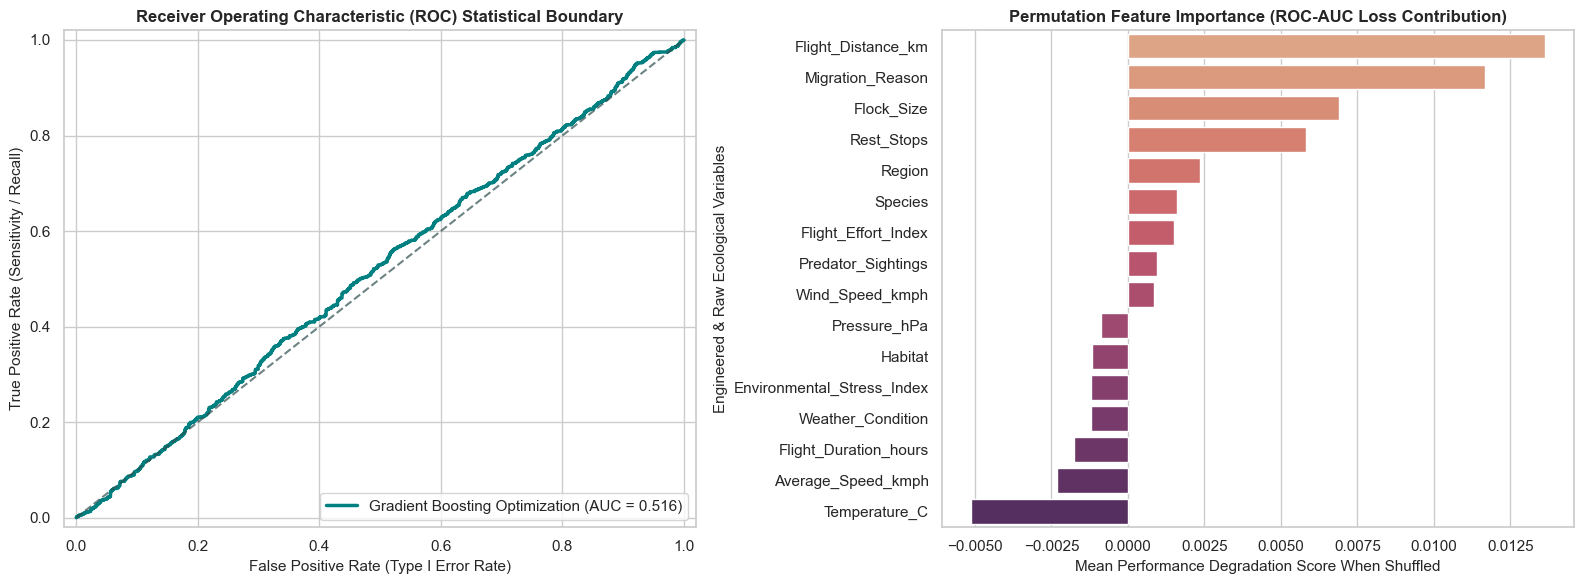

In [7]:
# Cell 4: Performance Evaluation & Statistical Graphics
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score
from sklearn.inspection import permutation_importance

def run_evaluation_and_plots(model, X_test, y_test):
    """Calculates verification metrics and generates model diagnostics plots."""
    # Generate class maps and continuous probability estimates
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print("\n============================================================")
    print("📋 AMAZON ML ACADEMY PERFORMANCE SPECIFICATION REPORT")
    print("============================================================\n")
    print(classification_report(y_test, y_pred, target_names=['Failed Migration', 'Successful Migration']))
    
    test_auc = roc_auc_score(y_test, y_prob)
    print(f"🏆 Final Verification Receiver Operating Characteristic AUC: {test_auc:.4f}\n")
    
    # Configure plotting environment
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # 📊 Graph 1: ROC Curve (Type I vs Type II Error Boundary Mapping)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[0].plot(fpr, tpr, color='teal', lw=2.5, label=f'Gradient Boosting Optimization (AUC = {test_auc:.3f})')
    ax[0].plot([0, 1], [0, 1], color='darkslategray', linestyle='--', alpha=0.7)
    ax[0].set_xlim([-0.02, 1.02])
    ax[0].set_ylim([-0.02, 1.02])
    ax[0].set_xlabel('False Positive Rate (Type I Error Rate)', fontsize=11)
    ax[0].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
    ax[0].set_title('Receiver Operating Characteristic (ROC) Statistical Boundary', fontsize=12, weight='bold')
    ax[0].legend(loc="lower right")
    
    # 📊 Graph 2: Permutation Feature Importance Map
    print("📊 Computing Permutation Feature Importance weights...")
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=config.RANDOM_SEED, scoring='roc_auc')
    sorted_importances_idx = result.importances_mean.argsort()[::-1]
    
    perm_importance_df = pd.DataFrame({
        'Feature': X_test.columns[sorted_importances_idx],
        'Importance_Drop': result.importances_mean[sorted_importances_idx]
    })
    
    sns.barplot(data=perm_importance_df, x='Importance_Drop', y='Feature', ax=ax[1], palette='flare')
    ax[1].set_title('Permutation Feature Importance (ROC-AUC Loss Contribution)', fontsize=12, weight='bold')
    ax[1].set_xlabel('Mean Performance Degradation Score When Shuffled', fontsize=11)
    ax[1].set_ylabel('Engineered & Raw Ecological Variables', fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Execute evaluation pipeline
run_performance_plots = run_evaluation_and_plots(optimized_pipeline, X_test, y_test)